In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

Regression functions

In [118]:
def fit_stokes_from_window(theta_rad, I_theta):
    """
    Reconstruct the Stokes vector from one angular/temporal window.

    The measured curve is fitted to the harmonic model:

        I(theta) = a0 + a2*sin(2theta) + a4c*cos(4theta) + a4s*sin(4theta)

    and the Stokes parameters are recovered through:

        S1 = 4 a4c
        S2 = 4 a4s
        S3 = -2 a2
        S0 = 2 a0 - 2 a4c

    Parameters
    ----------
    theta_rad : array
        QWP angles inside the selected window.
    I_theta : array
        Intensity values measured in the same window.

    Returns
    -------
    S_fit : ndarray
        Reconstructed Stokes vector [S0, S1, S2, S3].
    coeffs : ndarray
        Fitted harmonic coefficients [a0, a2, a4c, a4s].
    """
    # Build the linear design matrix for least-squares fitting
    A = np.column_stack([
        np.ones_like(theta_rad),
        np.sin(2.0 * theta_rad),
        np.cos(4.0 * theta_rad),
        np.sin(4.0 * theta_rad),
    ])


    # Solve the linear least-squares problem
    coeffs, *_ = np.linalg.lstsq(A, I_theta, rcond=None)
    a0, a2, a4c, a4s = coeffs

    # Convert harmonic coefficients into the Stokes parameters
    S1 = 4.0 * a4c
    S2 = 4.0 * a4s
    S3 = -2.0 * a2
    S0 = 2.0 * a0 - 2.0 * a4c

    print('Coefficients S0, S1, S2, S3: \n', S0, S1, S2, S3)

    return np.array([S0, S1, S2, S3]), coeffs

In [119]:
def normalize_stokes(S):
    """
    Normalize the Stokes vector and compute the degree of polarization.

    Parameters
    ----------
    S : array-like
        Stokes vector [S0, S1, S2, S3].

    Returns
    -------
    s : ndarray
        Normalized Stokes vector [s1, s2, s3].
    dop : float
        Degree of polarization.
    """
    S0, S1, S2, S3 = S
    s = np.array([S1 / S0, S2 / S0, S3 / S0])
    dop = np.sqrt(S1**2 + S2**2 + S3**2) / S0
    return s, dop

In [139]:
offset = 0.00182

In [140]:
medicion = pd.read_csv('Measurements/medicion_manual_v0.1.csv')
medicion['voltaje'] = medicion['voltaje'] - offset
medicion['rad'] = medicion['angulo']*np.pi/180
medicion.head()

,angulo,voltaje,rad
0,0,0.034577,0.000000
1,2,0.032154,0.034907
2,4,0.028125,0.069813
3,6,0.024189,0.104720
4,8,0.021522,0.139626


In [121]:
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = medicion['rad'][peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
norm_number


np.float64(0.04869499999999992)

In [ ]:

medicion['voltaje_norm'] = (medicion['voltaje'])/ norm_number
medicion.head()


,angulo,voltaje,rad,voltaje_norm
0,0,0.036397,0.000000,0.747444
1,2,0.033974,0.034907,0.697681
2,4,0.029945,0.069813,0.614946
3,6,0.026009,0.104720,0.534116
4,8,0.023342,0.139626,0.479359


In [123]:

S, coeffs = fit_stokes_from_window(medicion['rad'], medicion['voltaje_norm'])

s, dop = normalize_stokes(S)


Coefficients S0, S1, S2, S3: 
 0.7157407179945561 0.6963562840597177 -1.730061502175047 -0.03320390535573248


In [124]:
coeffs

array([ 0.53195943,  0.01660195,  0.17408907, -0.43251538])

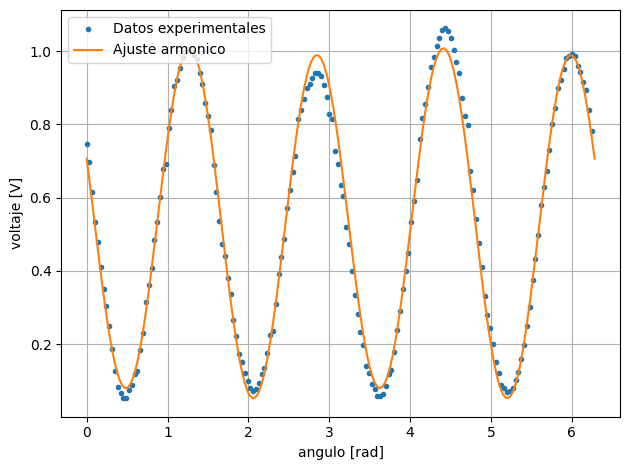

In [125]:
theta = np.linspace(0,2*np.pi,200)

I = lambda a0, a2, a4c, a4s, theta: a0 + a2*np.sin(2*theta) + a4c*np.cos(4*theta) + a4s*np.sin(4*theta)

plt.figure()
plt.plot(medicion['rad'], medicion['voltaje_norm'],'.',label = 'Datos experimentales')
plt.plot(theta, I(*coeffs, theta),'-', label = 'Ajuste armonico')


plt.legend(loc = 'upper left')
plt.xlabel('angulo [rad]')
plt.ylabel('voltaje [V]')
plt.grid()
plt.tight_layout()



In [126]:
peaks_volt = find_peaks(medicion['voltaje_norm'])[0]
peaks_angle = medicion['rad'][peaks_volt]
norm_number = medicion['voltaje_norm'][peaks_volt].mean()
norm_number

np.float64(1.0)

In [127]:
dop

np.float64(2.606030174064715)

In [128]:
S

array([ 0.71574072,  0.69635628, -1.7300615 , -0.03320391])

In [129]:
s

array([ 0.97291696, -2.41716233, -0.04639097])

In [130]:
np.sqrt(S[1]**2 + S[2]**2 + S[3]**2)

np.float64(1.865241907900557)

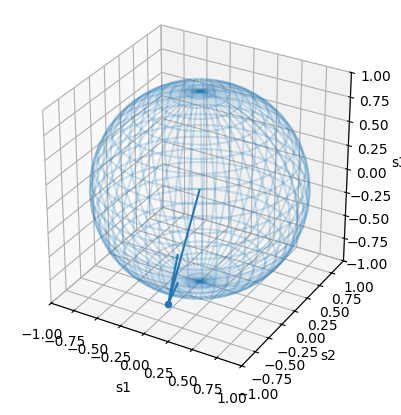

In [131]:
#PARA PLOTEAR EL PUNTO EN LA ESFERA 
raiz = np.sqrt(S[1]**2 + S[2]**2 + S[3]**2)

max_int = medicion['voltaje_norm'].max()

s1, s2, s3 = S[1]/norm_number, S[2]/norm_number, S[3]/norm_number

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# --- esfera ---
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(x, y, z, alpha=0.2)

# --- vector (flecha) ---

ax.quiver(0, 0, 0, s1, s2, s3)

# --- punto final (opcional pero útil) ---
ax.scatter(s1, s2, s3)

# --- ejes ---
ax.set_xlabel("s1")
ax.set_ylabel("s2")
ax.set_zlabel("s3")

ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

ax.set_box_aspect([1,1,1])

In [132]:
max_int

np.float64(1.0614642160386094)

In [133]:
raiz

np.float64(1.865241907900557)

In [134]:
print(S)

[ 0.71574072  0.69635628 -1.7300615  -0.03320391]


In [141]:
(medicion['voltaje'].max()- medicion['voltaje'].min())/(medicion['voltaje'].max()+medicion['voltaje'].min())

np.float64(0.9716906531709631)